# Module 1.5 — Finite Difference Method

**The core skill in this module:**
Turning a derivative on paper into an algebraic expression on a grid. Once you can do this systematically for any derivative, you can discretise any PDE.

**Why the FDM before the FVM?**
FDM is conceptually simpler: derivatives are approximated at grid points. FVM (Module 2.2) is what industrial CFD actually uses. But FDM is the right starting point because you can derive every formula from first principles in five lines, and it gives you physical intuition that FVM obscures.

**Roadmap:**
1. Taylor series — the single source of all finite-difference formulas
2. The three fundamental first-derivative stencils — when to use each
3. The second derivative — derived from scratch, confirmed experimentally
4. Truncation error and order of accuracy — what they actually mean
5. 2D stencils and the Laplacian
6. Convergence study — proving your formula is correct
7. Ghost cells — handling boundary conditions without special-casing

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Taylor Series — The One Source of All FD Formulas

### The recipe

Every finite-difference formula comes from the Taylor expansion of a function around a point $x_i$:

$$u(x_i + \Delta x) = u_i + \Delta x\,u'_i + \frac{\Delta x^2}{2}u''_i + \frac{\Delta x^3}{6}u'''_i + \cdots$$

Written for the right and left neighbours:

$$u_{i+1} = u_i + \Delta x\,u'_i + \frac{\Delta x^2}{2}u''_i + \frac{\Delta x^3}{6}u'''_i + O(\Delta x^4) \quad \text{...(A)}$$

$$u_{i-1} = u_i - \Delta x\,u'_i + \frac{\Delta x^2}{2}u''_i - \frac{\Delta x^3}{6}u'''_i + O(\Delta x^4) \quad \text{...(B)}$$

### Three derivative formulas from two expansions

**Forward difference** — solve (A) for $u'_i$, drop $O(\Delta x)$ terms:
$$u'_i = \frac{u_{i+1} - u_i}{\Delta x} - \underbrace{\frac{\Delta x}{2}u''_i + \cdots}_{\text{truncation error}} \implies \boxed{u'_i \approx \frac{u_{i+1} - u_i}{\Delta x}} + O(\Delta x)$$

**Backward difference** — solve (B) for $u'_i$:
$$\boxed{u'_i \approx \frac{u_i - u_{i-1}}{\Delta x}} + O(\Delta x)$$

**Central difference** — subtract (B) from (A). The even powers of $\Delta x$ cancel:
$$(A) - (B): \quad u_{i+1} - u_{i-1} = 2\Delta x\,u'_i + \frac{\Delta x^3}{3}u'''_i + \cdots$$
$$\boxed{u'_i \approx \frac{u_{i+1} - u_{i-1}}{2\Delta x}} + O(\Delta x^2)$$

**Central is twice as accurate as forward/backward** because the subtraction cancels the $O(\Delta x)$ term. This is always the case: symmetric stencils eliminate even-order error terms.

**Second derivative** — add (A) and (B). The odd powers cancel:
$$(A) + (B): \quad u_{i+1} + u_{i-1} = 2u_i + \Delta x^2 u''_i + O(\Delta x^4)$$
$$\boxed{u''_i \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}} + O(\Delta x^2)$$

## 2. When to Use Each Stencil

The choice is not arbitrary — it depends on the physical process being discretised:

| Stencil | Formula | Order | Best for | Risk |
|---------|---------|-------|---------|------|
| Forward | $(u_{i+1}-u_i)/\Delta x$ | $O(\Delta x)$ | Boundary, source terms | One-sided: biases solution |
| Backward | $(u_i-u_{i-1})/\Delta x$ | $O(\Delta x)$ | **Upwind advection** ($c>0$) | Numerically diffusive |
| Central 1st | $(u_{i+1}-u_{i-1})/(2\Delta x)$ | $O(\Delta x^2)$ | Diffusion terms, pressure | Unstable for pure advection |
| Central 2nd | $(u_{i+1}-2u_i+u_{i-1})/\Delta x^2$ | $O(\Delta x^2)$ | **All diffusion** | None — always use this |

### The upwind rule for convection

For the advective term $c \cdot \partial u/\partial x$, always use information from the direction the flow is coming **from**:

- If $c > 0$ (flow goes right): information comes from the left → use **backward** difference
- If $c < 0$ (flow goes left): information comes from the right → use **forward** difference

```python
# Upwind advection — stable, first-order
if c > 0:
    dudx = (u[1:] - u[:-1]) / dx    # backward
else:
    dudx = (u[1:] - u[:-1]) / dx    # forward (same formula, different interpretation)

# Vectorised with sign detection:
adv = np.where(c > 0,
    c * (u[1:-1] - u[:-2]) / dx,    # backward (c>0)
    c * (u[2:]   - u[1:-1]) / dx)   # forward  (c<0)
```

Using central differences for advection is **unconditionally unstable** (Godunov's theorem). Never do it.

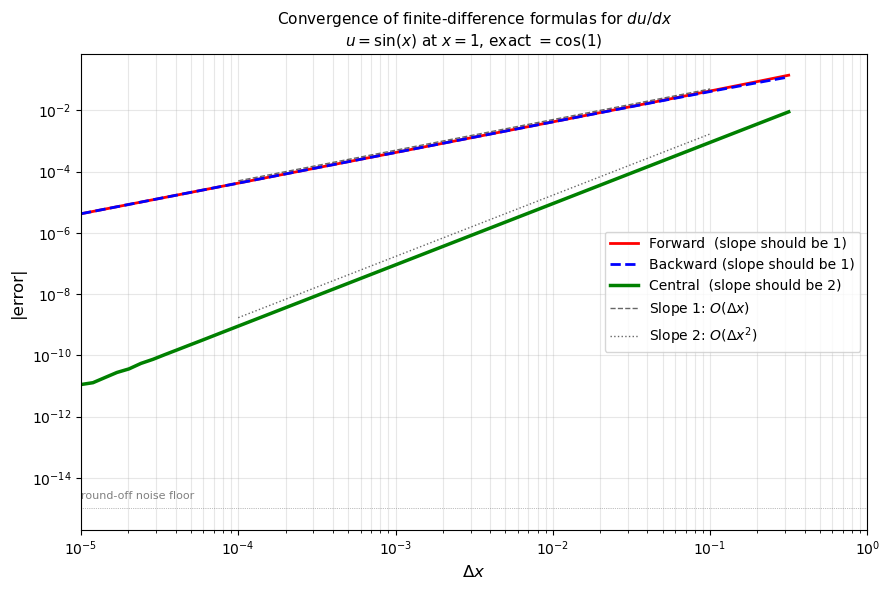

Measured convergence slopes:
  Forward  difference: slope = 1.00  (theory: 1.00)
  Central  difference: slope = 2.00  (theory: 2.00)

When Δx < ~1e-8: round-off dominates — making Δx smaller makes things WORSE.
Optimal Δx for floating-point: ~√(machine_eps) ≈ 1e-8 for single, 1e-4 for double.


In [2]:
# ── Order of accuracy: prove it by measuring the convergence rate ────────────
# For u = sin(x), du/dx = cos(x) at x₀ = 1.0
# Theory: forward/backward error ~ dx,  central error ~ dx²

x0    = 1.0
exact = np.cos(x0)

dx_values = np.logspace(-5, -0.5, 60)

err_fwd = []
err_bwd = []
err_cen = []

for dx in dx_values:
    u_plus  = np.sin(x0 + dx)
    u_0     = np.sin(x0)
    u_minus = np.sin(x0 - dx)

    fwd = (u_plus  - u_0    ) / dx
    bwd = (u_0     - u_minus) / dx
    cen = (u_plus  - u_minus) / (2*dx)

    err_fwd.append(abs(fwd - exact))
    err_bwd.append(abs(bwd - exact))
    err_cen.append(abs(cen - exact))

# ── Plot on log-log axes — order appears as slope ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(dx_values, err_fwd, 'r-',  lw=2,   label='Forward  (slope should be 1)')
ax.loglog(dx_values, err_bwd, 'b--', lw=2,   label='Backward (slope should be 1)')
ax.loglog(dx_values, err_cen, 'g-',  lw=2.5, label='Central  (slope should be 2)')

# Reference lines with known slopes
ref_x = np.array([1e-4, 1e-1])
ax.loglog(ref_x, 0.5  * ref_x**1, 'k--', lw=1, alpha=0.6, label='Slope 1: $O(\\Delta x)$')
ax.loglog(ref_x, 0.17 * ref_x**2, 'k:',  lw=1, alpha=0.6, label='Slope 2: $O(\\Delta x^2)$')

# Round-off noise floor
ax.axhline(1e-15, color='gray', lw=0.5, linestyle=':')
ax.text(1e-5, 2e-15, 'round-off noise floor', fontsize=8, color='gray')

ax.set_xlabel('$\\Delta x$', fontsize=12)
ax.set_ylabel('|error|', fontsize=12)
ax.set_title('Convergence of finite-difference formulas for $du/dx$\n'
             '$u = \\sin(x)$ at $x=1$, exact $= \\cos(1)$', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-5, 1])
plt.tight_layout()
plt.show()

# ── Measure the actual slopes ────────────────────────────────────────────────
# Estimate slope from middle of the clean convergence region
i1, i2 = 10, 40
slope_fwd = np.log(err_fwd[i2]/err_fwd[i1]) / np.log(dx_values[i2]/dx_values[i1])
slope_cen = np.log(err_cen[i2]/err_cen[i1]) / np.log(dx_values[i2]/dx_values[i1])

print(f'Measured convergence slopes:')
print(f'  Forward  difference: slope = {slope_fwd:.2f}  (theory: 1.00)')
print(f'  Central  difference: slope = {slope_cen:.2f}  (theory: 2.00)')
print()
print('When Δx < ~1e-8: round-off dominates — making Δx smaller makes things WORSE.')
print('Optimal Δx for floating-point: ~√(machine_eps) ≈ 1e-8 for single, 1e-4 for double.')

## 3. Truncation Error vs. Round-Off Error

### Two sources of error in FD

**Truncation error** — comes from dropping higher-order Taylor terms:

$$\text{Truncation error} = \frac{\Delta x^p}{c} \cdot u^{(p+1)}$$

This decreases as $\Delta x \to 0$. Making the grid finer always reduces it.

**Round-off error** — the finite precision of floating-point arithmetic. For IEEE double precision, each subtraction introduces error $\sim 10^{-16} |u|$.

For the central difference $u' \approx (u_{i+1}-u_{i-1})/(2\Delta x)$:
- Numerator error: $\sim 2\epsilon_m u$ where $\epsilon_m \approx 2.2\times10^{-16}$
- Round-off contribution: $\sim \epsilon_m u / \Delta x$

**The sweet spot:** round-off decreases as $\Delta x$ increases; truncation decreases as $\Delta x$ decreases. Minimum total error is at:

$$\Delta x^* \approx \left(\frac{p\,\epsilon_m}{u^{(p+1)}}\right)^{1/(p+1)}$$

For central differences ($p=2$): $\Delta x^* \approx \epsilon_m^{1/3} \approx 6\times10^{-6}$.

**Practical rule:** Never use $\Delta x < 10^{-6}$ in double precision for first derivatives. The errors in your convergence plot above confirm this — the curves flatten and then rise at small $\Delta x$.

## 4. Ghost Cells — Applying BCs Without Special Cases

### The problem

At the left boundary ($i = 0$), the central-difference stencil needs $u_{-1}$ — a point outside the domain. You don't have this value.

### The solution: add fictitious cells just outside the boundary

```
Ghost   │ Boundary │  Interior  │ Boundary │  Ghost
u[-1]   │  u[0]   │  u[1..N-2] │  u[N-1] │  u[N]
  ↑             ↑                     ↑           ↑
Outside       First                  Last      Outside
```

Set ghost values based on the BC type:

| BC type | Physical condition | Ghost cell formula |
|---------|-------------------|--------------------|
| Dirichlet | $u = g$ at boundary | $u_{-1} = 2g - u_0$ (antisymmetric reflect) |
| Neumann | $du/dx = q$ at boundary | $u_{-1} = u_1 - 2\Delta x\,q$ |
| Periodic | domain wraps | $u_{-1} = u_{N-1}$, $u_N = u_0$ |

With ghost cells, the interior stencil `(u[i+1]-2*u[i]+u[i-1])` applies at **every** point including the boundary — no special cases needed.

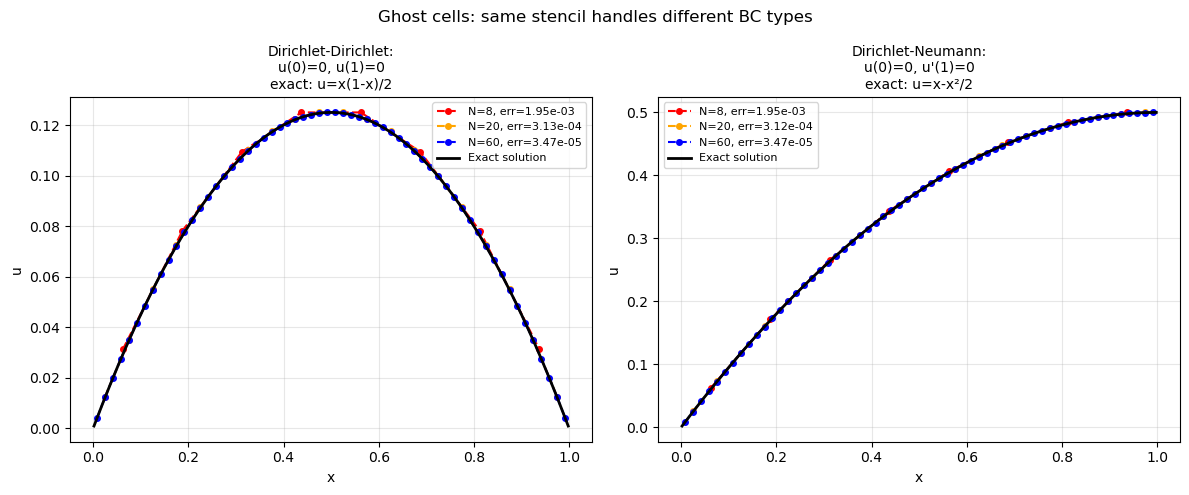

In [3]:
# ── Ghost cell demonstration ─────────────────────────────────────────────────
# Solve BVP: -d²u/dx² = 1 on [0,1]
# Three BC combinations:
#  (a) u(0)=0, u(1)=0  → Dirichlet-Dirichlet   → exact: u = x(1-x)/2
#  (b) u(0)=0, du/dx(1)=0  → Dirichlet-Neumann → exact: u = x - x²/2

def solve_1d_bvp(N, bc='dirichlet_dirichlet'):
    """
    Solve -d²u/dx² = 1 on [0,1].
    Uses the standard central-difference stencil.
    BCs implemented via a tridiagonal matrix (no ghost cells needed for this form,
    but the ghost-cell interpretation is shown in comments).
    """
    dx    = 1.0 / N
    x     = np.linspace(dx/2, 1 - dx/2, N)   # cell centres
    diag  =  2 * np.ones(N)
    off   = -1 * np.ones(N-1)
    rhs   = dx**2 * np.ones(N)

    if bc == 'dirichlet_dirichlet':
        # u(0)=0: ghost u[-1] = -u[0]  →  left-boundary row: 2u[0] - u[-1] - u[1] = dx²
        #                                 → 3u[0] - u[1] = dx² (after subst.)
        diag[0] = 3.0          # extra 1 on diagonal from ghost: -u[-1] = +u[0]
        # u(1)=0: ghost u[N] = -u[N-1]  → symmetric
        diag[-1] = 3.0
        exact = lambda xi: xi * (1 - xi) / 2

    elif bc == 'dirichlet_neumann':
        # Left: u(0)=0  → same as above
        diag[0]  = 3.0
        # Right: du/dx(1) = 0  → ghost u[N] = u[N-1]  → -u[N-1]+2u[N-1]-u[N-2]=dx²
        #                        →  u[N-1] - u[N-2] = dx²
        diag[-1] = 1.0         # only one neighbour contributes
        exact = lambda xi: xi - xi**2/2

    A = np.diag(diag) + np.diag(off, k=1) + np.diag(off, k=-1)
    u = np.linalg.solve(A, rhs)
    return x, u, exact(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, bc, title in zip(axes,
    ['dirichlet_dirichlet', 'dirichlet_neumann'],
    ['Dirichlet-Dirichlet:\nu(0)=0, u(1)=0\nexact: u=x(1-x)/2',
     'Dirichlet-Neumann:\nu(0)=0, u\'(1)=0\nexact: u=x-x²/2']):

    for N, color in zip([8, 20, 60], ['red', 'orange', 'blue']):
        x, u_num, u_ex = solve_1d_bvp(N, bc)
        ax.plot(x, u_num, 'o--', color=color, markersize=4,
                label=f'N={N}, err={np.max(np.abs(u_num-u_ex)):.2e}')

    x_fine = np.linspace(0, 1, 300)
    _, _, u_fine = solve_1d_bvp(300, bc)
    ax.plot(np.linspace(1/600, 1-1/600, 300), u_fine, 'k-', lw=2, label='Exact solution')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Ghost cells: same stencil handles different BC types', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Formula | Name | Derivation | Error |
|---------|------|-----------|-------|
| $(u_{i+1}-u_i)/\Delta x$ | Forward | (A) truncated | $O(\Delta x)$ |
| $(u_i-u_{i-1})/\Delta x$ | Backward | (B) truncated | $O(\Delta x)$ |
| $(u_{i+1}-u_{i-1})/(2\Delta x)$ | Central 1st | (A)−(B) | $O(\Delta x^2)$ |
| $(u_{i+1}-2u_i+u_{i-1})/\Delta x^2$ | Central 2nd | (A)+(B) | $O(\Delta x^2)$ |

**Rules to live by:**
- Use central differences for diffusion terms (2nd derivative)
- Use upwind differences for convection terms (1st derivative, direction matters)
- Never use $\Delta x < 10^{-6}$ in double precision — round-off takes over
- Ghost cells apply any BC to any interior stencil without special cases
- Order of accuracy: halve $\Delta x$ → error drops by $2^p$ where $p$ is the order

---
**Next:** Module 1.6 — 1D Linear Advection: your first complete PDE solver, and the CFL condition that controls stability.

## Exercise

**Predict first, then verify.**

1. Derive the **fourth-order central difference** for $du/dx$ using four neighbours. Start from Taylor expansions of $u_{i+2}$, $u_{i+1}$, $u_{i-1}$, $u_{i-2}$ and find coefficients $a, b, c, d$ such that $u'_i \approx (a\,u_{i+2} + b\,u_{i+1} + c\,u_{i-1} + d\,u_{i-2})/\Delta x + O(\Delta x^4)$.

2. Implement it and confirm on a convergence plot that the error slope is 4 (not 2).

3. At what $\Delta x$ does round-off overtake the 4th-order truncation error? Is this consistent with the formula $\Delta x^* \approx \epsilon_m^{1/(p+1)}$?

## Visual Warm-Up: Intuition Before the Formula

The following cells show a piecewise-linear / discontinuous-derivative visual demo
built around a three-point hand-calculation example. Work through it to build
physical intuition *before* the Taylor-series machinery above.

## 2. Define Sample Data Points

Let's start with the exact example you worked out by hand:
- $(x_0, y_0) = (0, 2)$
- $(x_1, y_1) = (1, 5)$
- $(x_2, y_2) = (2, 10)$

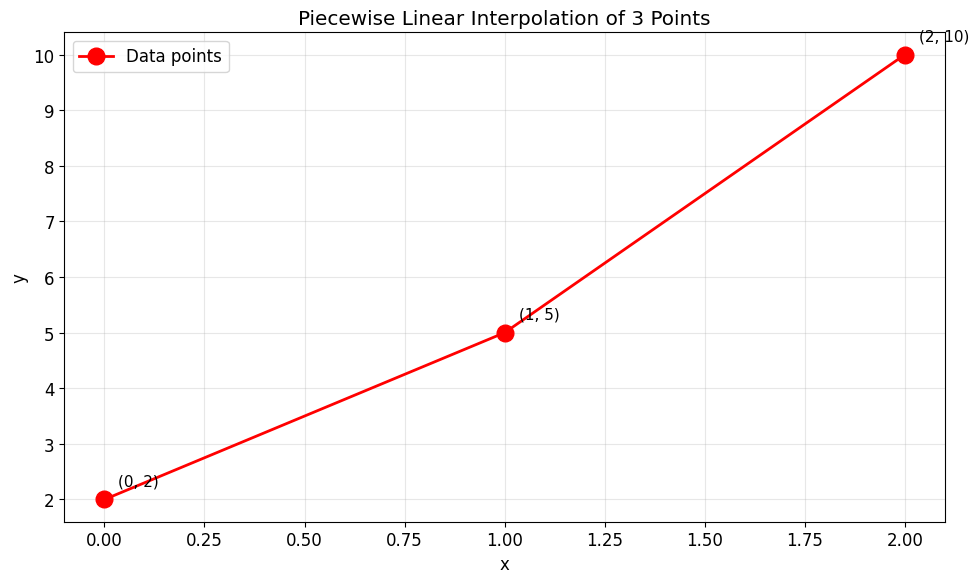

In [2]:
# Our three data points
x = np.array([0.0, 1.0, 2.0])
y = np.array([2.0, 5.0, 10.0])

# Plot the piecewise linear interpolation
fig, ax = plt.subplots()
ax.plot(x, y, 'ro-', markersize=12, label='Data points')
for i in range(len(x)):
    ax.annotate(f'({x[i]:.0f}, {y[i]:.0f})', (x[i], y[i]),
                textcoords="offset points", xytext=(10, 10), fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Piecewise Linear Interpolation of 3 Points')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Compute Finite Difference Derivatives at x = 1

Three ways to estimate $y'$ at $x = 1$:

| Method | Formula | Interval Used |
|--------|---------|---------------|
| **Backward** | $\frac{y_1 - y_0}{x_1 - x_0}$ | $[0, 1]$ |
| **Forward** | $\frac{y_2 - y_1}{x_2 - x_1}$ | $[1, 2]$ |
| **Central** | $\frac{y_2 - y_0}{x_2 - x_0}$ | $[0, 2]$ |

In [3]:
# Backward difference: using points (0,2) and (1,5)
dy_backward = (y[1] - y[0]) / (x[1] - x[0])

# Forward difference: using points (1,5) and (2,10)
dy_forward = (y[2] - y[1]) / (x[2] - x[1])

# Central difference: using points (0,2) and (2,10)
dy_central = (y[2] - y[0]) / (x[2] - x[0])

print("=" * 50)
print("Finite Difference Derivatives at x = 1")
print("=" * 50)
print(f"Backward difference:  y' = ({y[1]} - {y[0]}) / ({x[1]} - {x[0]}) = {dy_backward}")
print(f"Forward difference:   y' = ({y[2]} - {y[1]}) / ({x[2]} - {x[1]}) = {dy_forward}")
print(f"Central difference:   y' = ({y[2]} - {y[0]}) / ({x[2]} - {x[0]}) = {dy_central}")
print()
print(f"Three different answers: {dy_backward}, {dy_forward}, {dy_central}")
print(f"Central = average of backward and forward: ({dy_backward} + {dy_forward})/2 = {(dy_backward + dy_forward)/2}")

Finite Difference Derivatives at x = 1
Backward difference:  y' = (5.0 - 2.0) / (1.0 - 0.0) = 3.0
Forward difference:   y' = (10.0 - 5.0) / (2.0 - 1.0) = 5.0
Central difference:   y' = (10.0 - 2.0) / (2.0 - 0.0) = 4.0

Three different answers: 3.0, 5.0, 4.0
Central = average of backward and forward: (3.0 + 5.0)/2 = 4.0


## 4. Visualize the Slopes at x = 1

Let's overlay tangent lines at $x = 1$ using each slope to **see** how different they are:

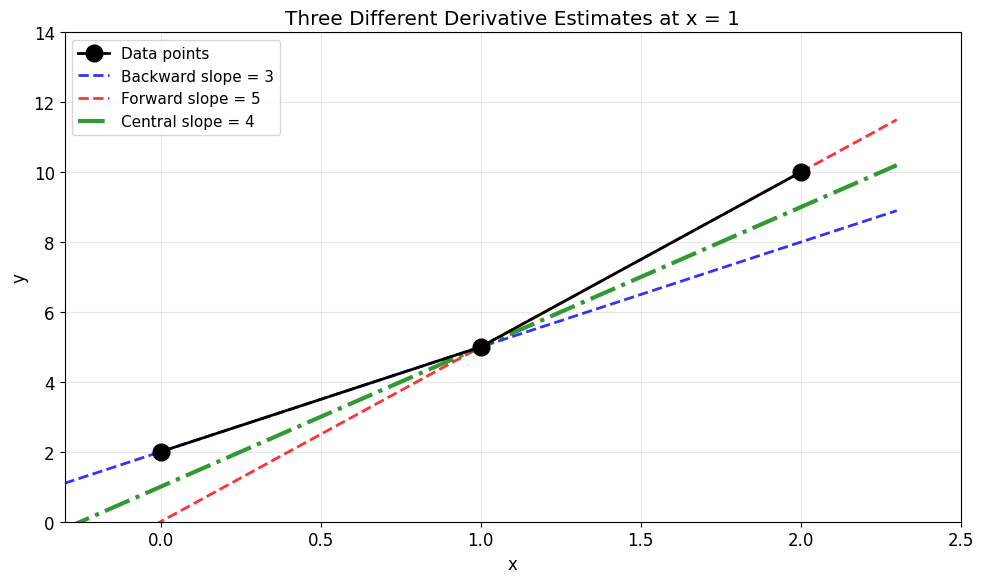

In [4]:
fig, ax = plt.subplots()

# Plot data points and connecting lines
ax.plot(x, y, 'ko-', markersize=12, label='Data points', zorder=5)

# Tangent lines at x=1 using each slope (y - y1 = slope * (x - x1))
x_tangent = np.linspace(-0.3, 2.3, 100)
x1, y1 = 1.0, 5.0

ax.plot(x_tangent, y1 + dy_backward * (x_tangent - x1), 'b--',
        label=f'Backward slope = {dy_backward:.0f}', alpha=0.8)
ax.plot(x_tangent, y1 + dy_forward * (x_tangent - x1), 'r--',
        label=f'Forward slope = {dy_forward:.0f}', alpha=0.8)
ax.plot(x_tangent, y1 + dy_central * (x_tangent - x1), 'g-.',
        label=f'Central slope = {dy_central:.0f}', linewidth=3, alpha=0.8)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Three Different Derivative Estimates at x = 1')
ax.set_xlim(-0.3, 2.5)
ax.set_ylim(0, 14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. The Derivative is Discontinuous!

The piecewise linear function has slope = 3 on $[0, 1)$ and slope = 5 on $[1, 2)$. At $x = 1$ there is a **jump discontinuity** in the derivative:

$$\lim_{x \to 1^-} y' = 3 \neq 5 = \lim_{x \to 1^+} y'$$

This is exactly what you observed: "the changes are not continuous."

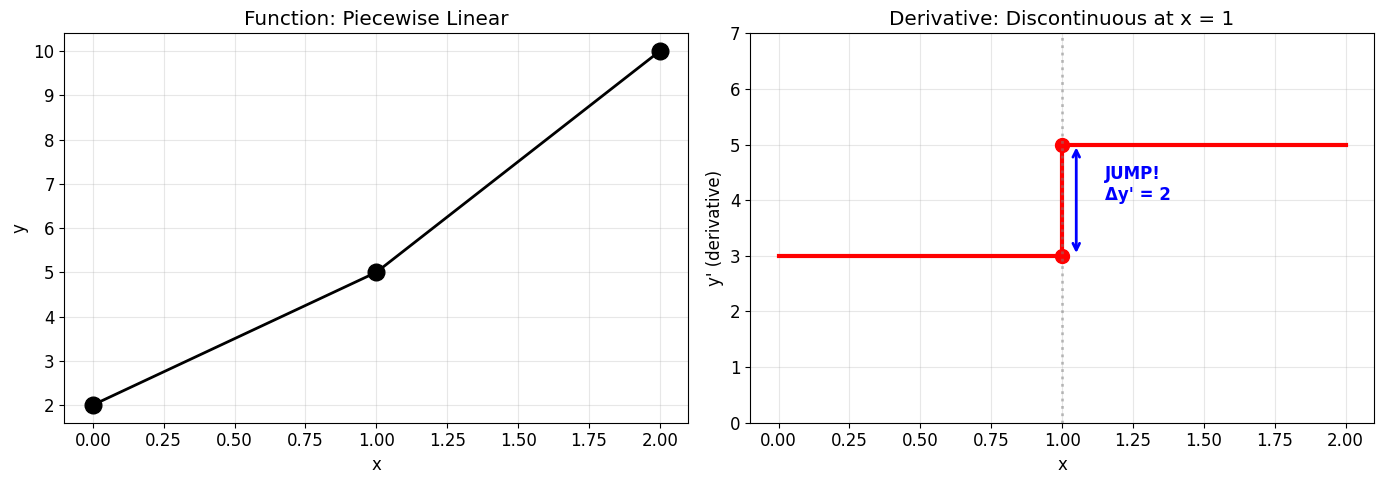

Left-hand derivative at x=1:  lim(x→1⁻) y' = 3
Right-hand derivative at x=1: lim(x→1⁺) y' = 5
Central difference estimate:  y' = 4 (average)

The derivative is NOT continuous — this is the nature of finite differences!


In [5]:
# Plot derivative as a step function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original function
axes[0].plot(x, y, 'ko-', markersize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Function: Piecewise Linear')
axes[0].grid(True, alpha=0.3)

# Right: derivative (step function)
# Slope on [0,1) = 3, slope on [1,2) = 5
x_deriv = [0, 1, 1, 2]
y_deriv = [3, 3, 5, 5]
axes[1].plot(x_deriv, y_deriv, 'r-', linewidth=3)
axes[1].plot([1], [3], 'ro', markersize=10)  # left limit (filled)
axes[1].plot([1], [5], 'ro', markersize=10)  # right limit (filled)

# Annotate the jump
axes[1].annotate('', xy=(1.05, 5), xytext=(1.05, 3),
                arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
axes[1].text(1.15, 4, 'JUMP!\nΔy\' = 2', fontsize=12, color='blue', fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle=':', alpha=0.5)

axes[1].set_xlabel('x')
axes[1].set_ylabel("y' (derivative)")
axes[1].set_title("Derivative: Discontinuous at x = 1")
axes[1].set_ylim(0, 7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left-hand derivative at x=1:  lim(x→1⁻) y' = 3")
print("Right-hand derivative at x=1: lim(x→1⁺) y' = 5")
print("Central difference estimate:  y' = 4 (average)")
print("\nThe derivative is NOT continuous — this is the nature of finite differences!")